# JXPaint Tutorial 1 — Quickstart: paint a tSZ map on the GPU

**JXPaint** paints beam-convolved Compton-$y$ Healpix maps from halo catalogues,
in pure Python + JAX on the GPU. It reproduces XGPaint's output *bit-for-bit*
(max pixel rel err $\sim10^{-10}$) while running in a fraction of a second per
catalogue.

In this notebook we:
1. load the beam-convolved shape table and a benchmark catalogue,
2. paint a full-sky map on the GPU,
3. validate it against the XGPaint reference map,
4. visualise the map.

> Run this notebook from the `tutorials/` directory.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.join("..", "src"))   # run from tutorials/
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import jax
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


## 1. Load the shape table and a catalogue

The catalogue columns are `z, M, lon, lat, snr, snr_true, y0_true, amp_noscatter`.
`M` is $M_{500c}$ in units of $10^{14}\,M_\odot$; `y0_true` is the central
Compton-$y$ amplitude used by the benchmark painter.

In [2]:
import pandas as pd
from jxpaint.profiles.shape_table import load_beamed_table

CAT = "/rds/rds-lxu/tsz_project/tsz_catalogue_benchmark/catalogue_bench_snr_0.csv"
REF = "/rds/rds-lxu/tsz_project/tsz_benchmark_maps_scatter/map_bench_snr_0_y0true.fits"

st = load_beamed_table()        # 8192x8192 beam-convolved bicubic shape table
df = pd.read_csv(CAT)
print(f"{len(df)} halos;  M range [1e14 Msun] = {df.M.min():.2f}..{df.M.max():.2f};"
      f"  z range = {df.z.min():.2f}..{df.z.max():.2f}")
df.head()

307170 halos;  M range [1e14 Msun] = 1.00..26.01;  z range = 0.01..2.81


,z,M,lon,lat,snr,snr_true,y0_true,amp_noscatter
0,0.161568,1.448139,3.220664,1.631829,0.828396,1.093318,0.000002,0.000003
1,0.706565,1.374127,4.255443,1.242116,0.178532,0.927557,0.000006,0.000005
2,1.456826,1.252370,2.787634,0.934283,0.127202,-1.377409,0.000011,0.000010
3,0.363908,1.512952,2.873445,1.952672,0.365178,1.752482,0.000004,0.000003
4,0.365934,1.264598,3.902037,0.683045,0.265961,0.303984,0.000003,0.000003


## 2. Paint the map on the GPU

`paint_catalogue_gpu_native` runs the *entire* pipeline on the GPU — geometry,
disc-finding, `pix2vec`, the bicubic shape lookup, and the scatter-add — with no
CPU host loop. The **first** call JIT-compiles the kernel (a few seconds); every
subsequent call (any catalogue or cosmology of the same size) reuses it.

In [3]:
from jxpaint.painting.gpu_native import paint_catalogue_gpu_native

z, M, lon, lat, y0 = (df.z.values, df.M.values, df.lon.values,
                      df.lat.values, df.y0_true.values)

t0 = time.time()
m = paint_catalogue_gpu_native(z, M, lon, lat, y0, st)   # first call: compiles
print(f"first call (incl. compile): {time.time()-t0:.2f} s")

t0 = time.time()
m = paint_catalogue_gpu_native(z, M, lon, lat, y0, st)   # warm
print(f"warm paint:                 {time.time()-t0:.3f} s")
print(f"map: nside=1024, nonzero={np.count_nonzero(m):,}, "
      f"max={m.max():.3e}, sum={m.sum():.4f}")

first call (incl. compile): 5.23 s
warm paint:                 0.184 s


map: nside=1024, nonzero=11,840,919, max=6.844e-05, sum=2.4217


## 3. Validate against the XGPaint reference map

The benchmark maps in `tsz_benchmark_maps_scatter/` were painted by the original
Julia XGPaint code. We compare pixel-by-pixel.

In [4]:
import healpy as hp
ref = hp.read_map(REF, dtype=np.float64)
mask = np.abs(ref) > 1e-9
rel = np.abs(m[mask] - ref[mask]) / np.abs(ref[mask])
print(f"max pixel rel err : {rel.max():.2e}   (tol 1e-5)")
print(f"RMS rel err       : {np.sqrt(np.mean(rel**2)):.2e}   (tol 1e-6)")
print(f"total flux rel err: {abs(m.sum()-ref.sum())/ref.sum():.2e}   (tol 1e-5)")
print(f"nonzero pixels    : jxpaint={np.count_nonzero(m):,}  ref={np.count_nonzero(ref):,}")

max pixel rel err : 1.14e-10   (tol 1e-5)
RMS rel err       : 2.60e-12   (tol 1e-6)
total flux rel err: 6.60e-15   (tol 1e-5)
nonzero pixels    : jxpaint=11,840,919  ref=11,840,919


## 4. Visualise

A gnomonic zoom on the most massive cluster, and a low-resolution full-sky view.

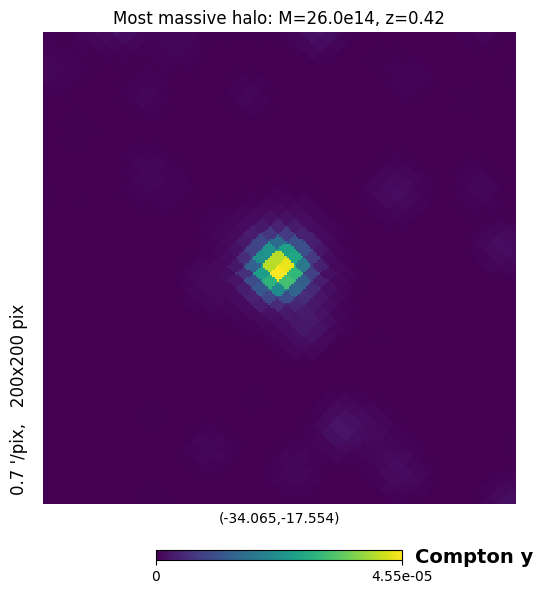

In [5]:
i_big = int(np.argmax(M))
ra = np.remainder(lon[i_big] + np.pi, 2*np.pi) - np.pi
dec = lat[i_big] - np.pi/2
hp.gnomview(m, rot=(np.degrees(ra), np.degrees(dec)), reso=0.7, xsize=200,
            title=f"Most massive halo: M={M[i_big]:.1f}e14, z={z[i_big]:.2f}",
            unit="Compton y", notext=False)
plt.show()

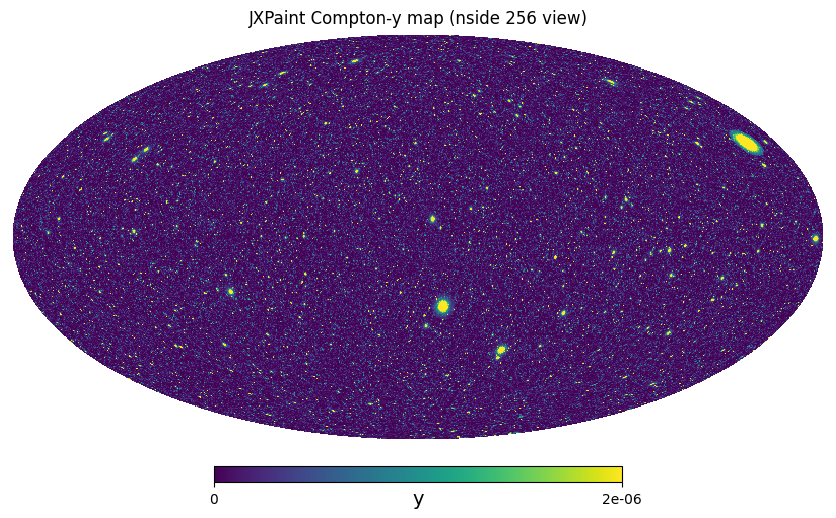

In [6]:
hp.mollview(hp.ud_grade(m, 256), title="JXPaint Compton-y map (nside 256 view)",
            unit="y", min=0, max=2e-6)
plt.show()

**Takeaway:** one GPU call paints a full nside=1024 Compton-$y$ map in ~0.2 s,
bit-for-bit identical to XGPaint. Next: [Tutorial 2](02_profiles.ipynb) on the
pressure profile physics.